In [99]:
from enum import IntEnum
from memo import memo

## Memo Model

In [100]:
class AgentType(IntEnum):
    Trustworthy = 0
    Untrustworthy = 1

class Action(IntEnum):
    Cooperate = 0
    Defect = 1

@memo
def trust_posterior[obs: Action](prior_trust, epsilon):
    """
    Memo model: posterior trust that Y is trustworthy (type 0)
    after observing a single action obs in {Cooperate, Defect}.

    prior_trust : P(Y_type = Trustworthy) before this round
    epsilon     : 'betrayal' noise parameter
    """
    return (
        (prior_trust *
         ((1 - epsilon) if obs == 0 else epsilon))
        /
        (
            prior_trust * ((1 - epsilon) if obs == 0 else epsilon)
            +
            (1 - prior_trust) * (epsilon if obs == 0 else (1 - epsilon))
        )
    )

### Python Wrapper

In [101]:
import numpy as np

def trust_posterior_scalar(prior_trust, epsilon, obs_idx, delta=1e-6):
    """
    Scalar wrapper around the memo trust_posterior model.

    prior_trust : current scalar trust (float in [0,1])
    epsilon     : betrayal noise
    obs_idx     : 0 for Cooperate, 1 for Defect
    delta       : small value to avoid p=0 or p=1 absorbing states
    """

    # Clamp trust so it never becomes literally 0 or 1
    p = float(prior_trust)
    p = min(max(p, delta), 1 - delta)

    # Call the MEMO model: returns a length-2 array over obs axis
    posterior_table = trust_posterior(p, epsilon)

    # Use the memo-computed posterior entry for the observed action
    return float(posterior_table[obs_idx])

### Simulation of Betrayal Dynamics

In [102]:
def simulate_betrayal_dynamics(
    n_rounds,
    prior_trust_init,
    epsilon,
    rng=None
):
    
    if rng is None:
        rng = np.random.default_rng()

    epsilon = float(epsilon)
    trust_values = [prior_trust_init]
    actions = [] 

    trust = prior_trust_init

    for t in range(n_rounds):
        action_probs = np.array([1 - epsilon, epsilon], dtype=float)
        observed_idx = rng.choice([0, 1], p=action_probs)
        observed = Action(observed_idx)
        actions.append(observed)

        trust = trust_posterior_scalar(trust, epsilon, observed_idx)
        trust_values.append(trust)

    return np.array(trust_values), np.array(actions)

In [103]:
trust_traj, acts = simulate_betrayal_dynamics(
    n_rounds=30,
    prior_trust_init=0.5,
    epsilon=0.1
)

### Plotting

In [104]:
import matplotlib.pyplot as plt

def plot_betrayal_dynamics(trust_traj, actions):
    rounds = np.arange(len(trust_traj))

    plt.figure(figsize=(12, 5))

    # Plot trust trajectory
    plt.plot(rounds, trust_traj, '-o', label='Trust', linewidth=2, markersize=4)

    # Overlay betrayal events
    betrayals = np.where(actions == Action.Defect)[0]
    plt.scatter(betrayals + 1, trust_traj[betrayals + 1], color='red', s=100, label='Betrayals')

    plt.ylim(0, 1)
    plt.xlabel("Round")
    plt.ylabel("Posterior trust in Y")
    plt.title("Trust Dynamics Under Occasional Betrayal (epsilon)")
    plt.grid(True)
    plt.legend()
    plt.show()

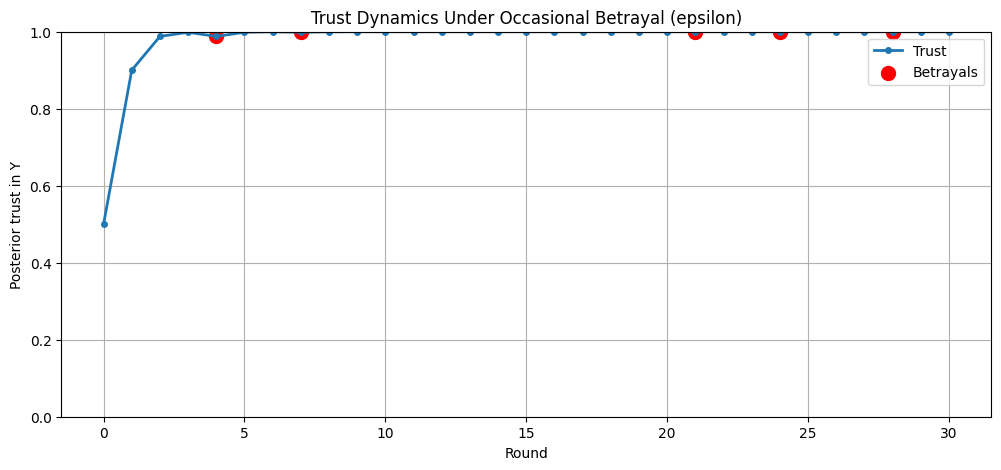

In [105]:
plot_betrayal_dynamics(trust_traj, acts)